# Semana 6 — Análisis de Impacto de Negocio



---

In [1]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

y_test      = joblib.load('y_test.pkl')
y_proba_xgb = np.load('y_proba_xgb.npy')
y_proba_rf  = np.load('y_proba_rf.npy')
y_proba_lr  = np.load('y_proba_lr.npy')

with open('model_config.json') as f:
    config = json.load(f)

COSTO_FN          = config['costo_fn']   # perder un cliente
COSTO_FP          = config['costo_fp']   # contactar innecesariamente
THRESHOLD         = config['threshold']

n_test            = len(y_test)
n_churn_real      = y_test.sum()
churn_rate_global = y_test.mean()

print(f'Clientes en test:    {n_test:,}')
print(f'Churns reales:       {n_churn_real:,}  ({churn_rate_global:.1%})')
print(f'Costo FN:            ${COSTO_FN}')
print(f'Costo FP:            ${COSTO_FP}')

Clientes en test:    1,409
Churns reales:       373  (26.5%)
Costo FN:            $500
Costo FP:            $30


---
## 1. Curva de Lift



In [2]:
def calcular_lift(y_true: np.ndarray, y_proba: np.ndarray, n_bins: int = 100):
    """
    Calcula la curva de lift ordenando por probabilidad descendente.
    Devuelve porcentaje de población contactada, porcentaje de churns capturados
    y el lift en cada punto.
    """
    df = pd.DataFrame({'y': y_true, 'p': y_proba})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)

    total_churn = df['y'].sum()
    n           = len(df)

    pct_poblacion   = []
    pct_churn_cap   = []
    lift_values     = []

    for i in range(1, n_bins + 1):
        corte = int(n * i / n_bins)
        churns_capturados = df.iloc[:corte]['y'].sum()
        pct_pob  = corte / n
        pct_cap  = churns_capturados / total_churn
        lift     = pct_cap / pct_pob if pct_pob > 0 else 0

        pct_poblacion.append(pct_pob)
        pct_churn_cap.append(pct_cap)
        lift_values.append(lift)

    return np.array(pct_poblacion), np.array(pct_churn_cap), np.array(lift_values)

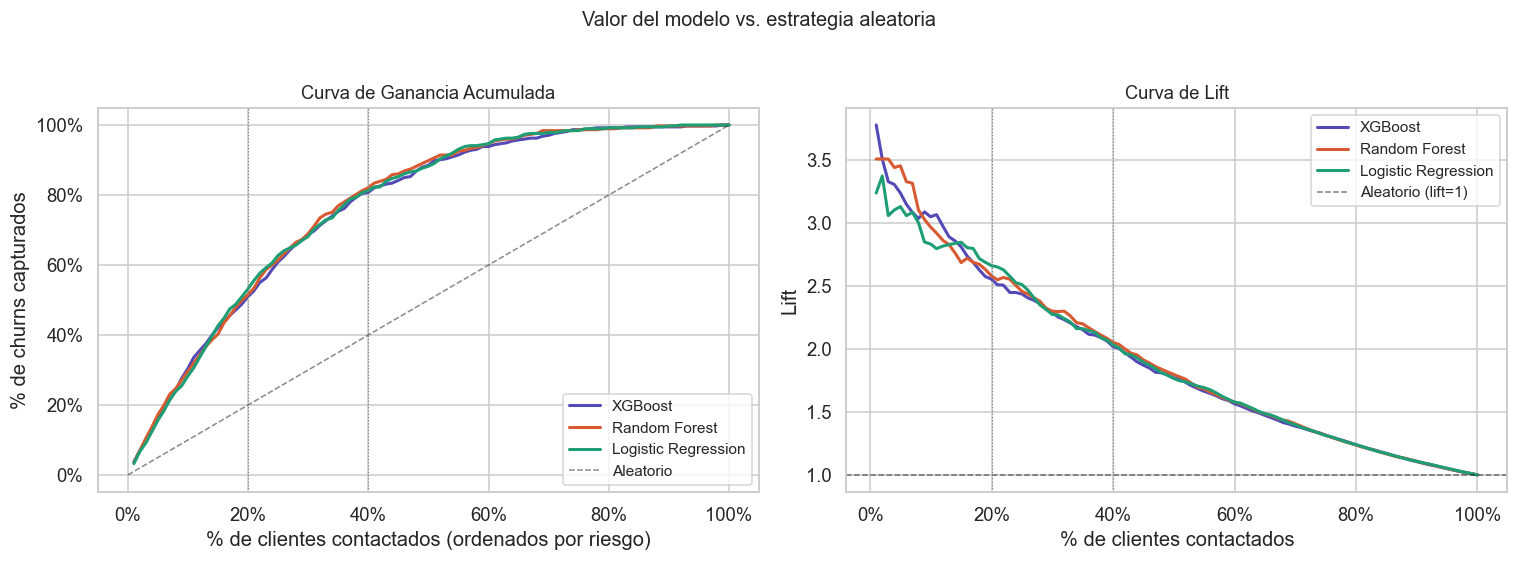

In [3]:
modelos = [
    ('XGBoost',              y_proba_xgb, '#534AB7'),
    ('Random Forest',        y_proba_rf,  '#D85A30'),
    ('Logistic Regression',  y_proba_lr,  '#1D9E75'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Curva de Ganancia Acumulada ──
ax = axes[0]
for name, proba, color in modelos:
    pct_pob, pct_cap, _ = calcular_lift(y_test.values, proba)
    ax.plot(pct_pob * 100, pct_cap * 100, color=color, linewidth=2, label=name)

ax.plot([0, 100], [0, 100], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')
ax.fill_between([0, 100], [0, 100], [0, 100], alpha=0.03, color='gray')
ax.axvline(20, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(40, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('% de clientes contactados (ordenados por riesgo)')
ax.set_ylabel('% de churns capturados')
ax.set_title('Curva de Ganancia Acumulada', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# ── Curva de Lift ──
ax = axes[1]
for name, proba, color in modelos:
    pct_pob, _, lift = calcular_lift(y_test.values, proba)
    ax.plot(pct_pob * 100, lift, color=color, linewidth=2, label=name)

ax.axhline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Aleatorio (lift=1)')
ax.axvline(20, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(40, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('% de clientes contactados')
ax.set_ylabel('Lift')
ax.set_title('Curva de Lift', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Valor del modelo vs. estrategia aleatoria', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_20_lift_ganancia.png', bbox_inches='tight')
plt.show()

---
## 2. Tabla de impacto por decil

separar  la población en 10 grupos iguales ordenados por riesgo descendente. Muestra cuántos churns hay en cada grupo y compara con el aleatorio.

In [7]:
df_decil = pd.DataFrame({
    'y':      y_test.values,
    'proba':  y_proba_xgb
}).sort_values('proba', ascending=False).reset_index(drop=True)

df_decil['decil'] = pd.qcut(df_decil.index, q=10, labels=range(1, 11))

tabla_decil = df_decil.groupby('decil').agg(
    n_clientes   = ('y', 'count'),
    n_churns     = ('y', 'sum'),
    proba_media  = ('proba', 'mean')
).reset_index()

tabla_decil['tasa_churn']     = tabla_decil['n_churns'] / tabla_decil['n_clientes']
tabla_decil['lift']           = tabla_decil['tasa_churn'] / churn_rate_global
tabla_decil['pct_churns_cap'] = tabla_decil['n_churns'].cumsum() / n_churn_real

tabla_decil.columns = ['Decil', 'Clientes', 'Churns', 'P media',
                        'Tasa churn', 'Lift', '% capturados (acum.)']

fmt = {
    'P media':             '{:.3f}',
    'Tasa churn':                 '{:.1%}',
    'Lift':                       '{:.2f}',
    '% capturados (acum.)':'{:.1%}'
}
print('=== TABLA DE LIFT POR DECIL — XGBoost ===')
print('Decil 1 = clientes con mayor riesgo predicho')
print()
print(tabla_decil.to_string(index=False,
      formatters={k: (lambda v, f=f: f.format(v)) for k, f in fmt.items()}))

=== TABLA DE LIFT POR DECIL — XGBoost ===
Decil 1 = clientes con mayor riesgo predicho

Decil  Clientes  Churns P media Tasa churn Lift % capturados (acum.)
    1       141     113   0.910      80.1% 3.03                30.3%
    2       141      78   0.796      55.3% 2.09                51.2%
    3       141      65   0.679      46.1% 1.74                68.6%
    4       141      45   0.552      31.9% 1.21                80.7%
    5       141      29   0.411      20.6% 0.78                88.5%
    6       140      20   0.280      14.3% 0.54                93.8%
    7       141      12   0.161       8.5% 0.32                97.1%
    8       141       8   0.072       5.7% 0.21                99.2%
    9       141       1   0.026       0.7% 0.03                99.5%
   10       141       2   0.008       1.4% 0.05               100.0%


---
## 3. Análisis de impacto económico por segmento

¿Cuánto vale contactar al top 10%, 20% y 30% de clientes según el modelo vs. una estrategia aleatoria?

In [8]:
TASA_RETENCION  = 0.30   # % de churners que se retienen si son contactados
VALOR_CLIENTE   = COSTO_FN  # valor promedio de un cliente retenido

cortes = [0.10, 0.20, 0.30, 0.40, 0.50]

rows = []
for corte in cortes:
    n_contactar   = int(n_test * corte)

    # Estrategia con modelo: contactar los n_contactar de mayor riesgo
    idx_modelo    = np.argsort(y_proba_xgb)[::-1][:n_contactar]
    churns_modelo = y_test.values[idx_modelo].sum()

    # Estrategia aleatoria: contactar n_contactar al azar
    churns_random = int(n_contactar * churn_rate_global)

    retenidos_modelo = int(churns_modelo * TASA_RETENCION)
    retenidos_random = int(churns_random * TASA_RETENCION)

    valor_modelo  = retenidos_modelo * VALOR_CLIENTE - n_contactar * COSTO_FP
    valor_random  = retenidos_random * VALOR_CLIENTE - n_contactar * COSTO_FP
    valor_extra   = valor_modelo - valor_random

    rows.append({
        '% contactados':       f'{corte:.0%}',
        'N contactar':         n_contactar,
        'Churns (modelo)':     churns_modelo,
        'Churns (aleatorio)':  churns_random,
        'Retenidos (modelo)':  retenidos_modelo,
        'Retenidos (aleatorio)': retenidos_random,
        'Valor neto (modelo)': f'${valor_modelo:,.0f}',
        'Valor neto (aleat.)': f'${valor_random:,.0f}',
        'Valor EXTRA modelo':  f'${valor_extra:,.0f}'
    })

df_impacto = pd.DataFrame(rows)
print(f'Supuestos: tasa retención si se contacta={TASA_RETENCION:.0%} | valor cliente=${VALOR_CLIENTE} | costo contacto=${COSTO_FP}')
print()
print(df_impacto.to_string(index=False))

Supuestos: tasa retención si se contacta=30% | valor cliente=$500 | costo contacto=$30

% contactados  N contactar  Churns (modelo)  Churns (aleatorio)  Retenidos (modelo)  Retenidos (aleatorio) Valor neto (modelo) Valor neto (aleat.) Valor EXTRA modelo
          10%          140              113                  37                  33                     11             $12,300              $1,300            $11,000
          20%          281              190                  74                  57                     22             $20,070              $2,570            $17,500
          30%          422              256                 111                  76                     33             $25,340              $3,840            $21,500
          40%          563              301                 149                  90                     44             $28,110              $5,110            $23,000
          50%          704              330                 186                  9

---
## 4. Visualización del impacto económico

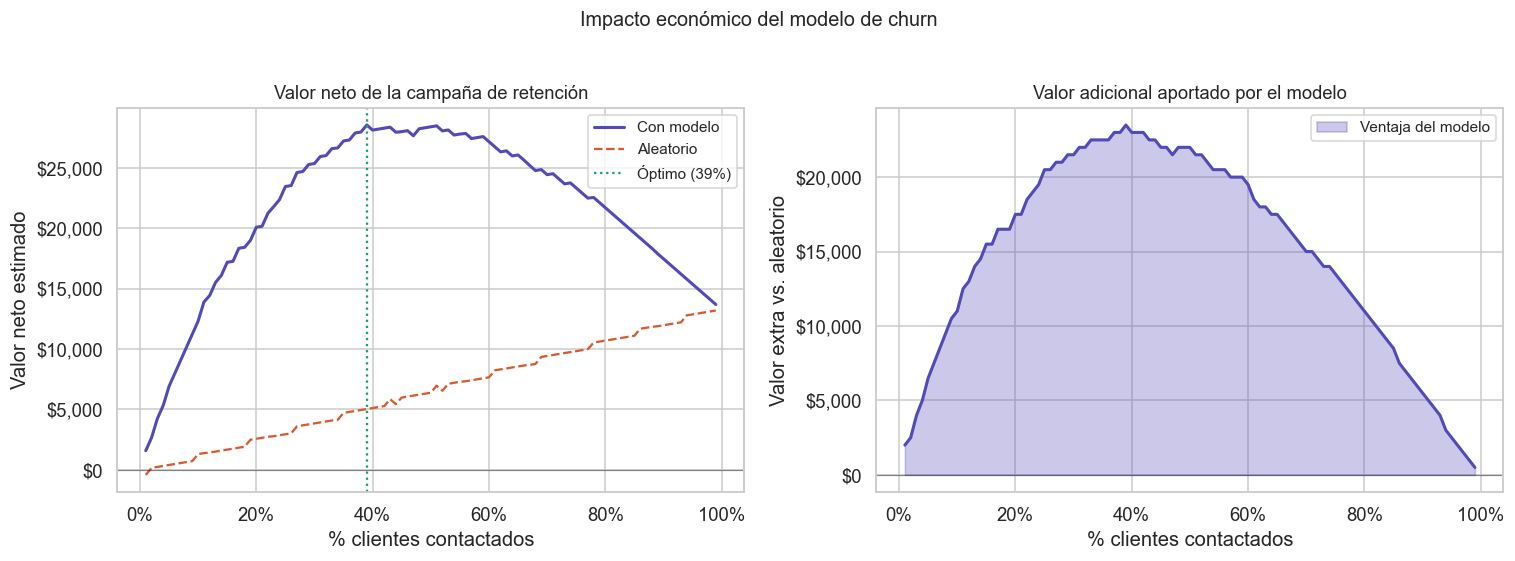

Punto óptimo de contacto: 39% de los clientes
Valor neto máximo estimado: $28,530


In [9]:
cortes_plot   = np.arange(0.01, 1.0, 0.01)
valor_modelo_plot  = []
valor_random_plot  = []

for corte in cortes_plot:
    n_c = int(n_test * corte)

    idx_m       = np.argsort(y_proba_xgb)[::-1][:n_c]
    churns_m    = y_test.values[idx_m].sum()
    churns_r    = int(n_c * churn_rate_global)

    vm = int(churns_m * TASA_RETENCION) * VALOR_CLIENTE - n_c * COSTO_FP
    vr = int(churns_r * TASA_RETENCION) * VALOR_CLIENTE - n_c * COSTO_FP

    valor_modelo_plot.append(vm)
    valor_random_plot.append(vr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valor neto absoluto
ax = axes[0]
ax.plot(cortes_plot * 100, valor_modelo_plot, color='#534AB7', linewidth=2, label='Con modelo')
ax.plot(cortes_plot * 100, valor_random_plot, color='#D85A30', linewidth=1.5,
        linestyle='--', label='Aleatorio')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
best_corte_idx = np.argmax(valor_modelo_plot)
ax.axvline(cortes_plot[best_corte_idx] * 100, color='#1D9E75',
           linewidth=1.5, linestyle=':', label=f'Óptimo ({cortes_plot[best_corte_idx]:.0%})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('% clientes contactados')
ax.set_ylabel('Valor neto estimado')
ax.set_title('Valor neto de la campaña de retención', fontsize=12)
ax.legend(fontsize=10)

# Valor extra del modelo vs aleatorio
ax = axes[1]
valor_extra_plot = np.array(valor_modelo_plot) - np.array(valor_random_plot)
ax.fill_between(cortes_plot * 100, valor_extra_plot, 0,
                where=(valor_extra_plot > 0), alpha=0.3, color='#534AB7', label='Ventaja del modelo')
ax.plot(cortes_plot * 100, valor_extra_plot, color='#534AB7', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('% clientes contactados')
ax.set_ylabel('Valor extra vs. aleatorio')
ax.set_title('Valor adicional aportado por el modelo', fontsize=12)
ax.legend(fontsize=10)

plt.suptitle('Impacto económico del modelo de churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_21_impacto_economico.png', bbox_inches='tight')
plt.show()

print(f'Punto óptimo de contacto: {cortes_plot[best_corte_idx]:.0%} de los clientes')
print(f'Valor neto máximo estimado: ${max(valor_modelo_plot):,.0f}')

---
## 5. Resumen 

In [10]:
pct_pob_20, pct_cap_20, lift_20 = calcular_lift(y_test.values, y_proba_xgb)
idx_20 = np.argmin(np.abs(pct_pob_20 - 0.20))

print('=== RESUMEN EJECUTIVO ===')
print()
print(f'Contactando al 20% de clientes con mayor riesgo predicho:')
print(f'  Churns capturados:  {pct_cap_20[idx_20]:.0%} del total')
print(f'  Lift:               {lift_20[idx_20]:.1f}x vs. contacto aleatorio')
print()
print('En términos de negocio:')

n_c_20        = int(n_test * 0.20)
idx_m_20      = np.argsort(y_proba_xgb)[::-1][:n_c_20]
churns_m_20   = y_test.values[idx_m_20].sum()
churns_r_20   = int(n_c_20 * churn_rate_global)
ret_m_20      = int(churns_m_20 * TASA_RETENCION)
ret_r_20      = int(churns_r_20 * TASA_RETENCION)
extra_ret     = ret_m_20 - ret_r_20
valor_extra   = extra_ret * VALOR_CLIENTE

print(f'  Clientes adicionales retenidos vs. aleatorio: +{extra_ret}')
print(f'  Valor económico adicional estimado:           ${valor_extra:,.0f}')
print()

=== RESUMEN EJECUTIVO ===

Contactando al 20% de clientes con mayor riesgo predicho:
  Churns capturados:  51% del total
  Lift:               2.6x vs. contacto aleatorio

En términos de negocio:
  Clientes adicionales retenidos vs. aleatorio: +35
  Valor económico adicional estimado:           $17,500



---
## 6. Guardar resultados

In [11]:
tabla_decil.to_csv('tabla_lift_decil.csv', index=False)
df_impacto.to_csv('tabla_impacto_economico.csv', index=False)

print('Guardado: tabla_lift_decil.csv, tabla_impacto_economico.csv')

Guardado: tabla_lift_decil.csv, tabla_impacto_economico.csv
